# Final Project-Machine Learning and AI

**Predicting S\&P 500 Index Movements Using Machine Learning Techniques**

## Problem Formulation:

**Problem Statement:**
The objective of this project is to predict the directional movement of the S\&P 500 index using historical market data. The machine learning techniques will allow for the prediction of whether the closing price of the index will decrease or increase on the next trading day, based on the previous data available.

**Background:**
The Standard and Poor's 500, abbreviated as S\&P 500, is a stock market index that collectively represents 500 large publicly traded US companies.

An index is a statistical measure that tracks the performance of a group of assets, such as stocks or bonds, quantifying the collective performance of a market segment. These are often used as an indicator of overall market trends.

The companies that make up the S\&P 500 index are weighted by market capitalisation, meaning that the larger companies (e.g Apple, Tesla and Microsoft) have more influence on the overall index's movement. This makes it a strong measure of the U.S economy and is a key indicator of overall market direction.

Being able to accurately predict the movement in the S\&P 500 is of utmost importance for financial analysts, traders and portfolio managers, due to its ability to provide insights into overall market trends.

Stock prices are influenced by various complex factors, such as corporate earnings, investor sentiment and external events, so accurate predictions of the financial time series are often difficult to make with traditional methods.

This is where machine learning techniques can shine as they allow for better handling of complex datasets through capturing non-linear relationships and hidden patterns. Through the use of feature engineering and the application of supervised learning algorithms, it is possible to construct predictive models that can extract meaningful indicators from real-world, complex data, allowing for improved predictions of market movements and providing a strong tool to inform financial decision-making.

However, it is important to acknowledge that the financial markets are dependent on various unpredictable external factors, including geopolitical events and changes in economic policies, which means that even the best models cannot achieve certain predictions. Even so, The ability to identify historical patterns and underlying relationships can still provide a predictive edge that can be used to improve investment decision-making and risk management, particularly during uncertain market conditions.

**Task Definition**
This task will be a binary classification problem:

Input Features:
Historical data, consisting of daily returns, moving averages, relative strength index, trading volume, etc, as well as engineered features (e.g. season).

Target Variable:
Binary label that will indicate whether the closing price for the next day will be higher (1) or lower (0) than the current day's closing price.

**Importance of problem:**

Accurately predicting the short-term movement of the S\&P 500 can offer major financial value, enabling improved trading strategies, better portfolio management and mitigating investment risk.

If we are able to produce a model that is even a marginal improvement over randomly guessing (50% baseline), this can still be used for meaningful gains when scaled appropriately in financial markets. Additionally, this project will provide an opportunity to apply the machine learning paradigm, including data preprocessing, feature engineering, model training, evaluation and hyperparameter tuning, into a real-world economic scenario.

**Dataset Description**

The dataset used for this project is the 'S\&P 500 Historical Data', obtained from Kaggle at [https://www.kaggle.com/datasets/henryhan117/sp-500-historical-data/data](https://www.kaggle.com/datasets/henryhan117/sp-500-historical-data/data). The dataset contains historical trading data for each trading day of the index from 1927 to 2020.

The dataset contains the following features:

-**Open**: The price of the index at market open on a given day.
-**High**: The peak price reached of the index during the trading day.
-**Low**: The lowest price reached of the index during the trading day.
-**Close**: The price of the index at market close on a given day.
-**Adj Close**: The closing prices after adjusting for dividends and stock splits.
-**Volume**: The total number of shares traded during a trading day.

These features provide a strong basis for feature engineering to create new predictive variables, such as moving averages or a target variable to indicate whether there has been an overall increase or  decrease in the index from the previous day.

The creation of new relevant features from the price and volume data is expected to enhance the model's ability  recognise patterns and make reliable predictions.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
#Load data-set
df = pd.read_csv('SPX.csv', parse_dates=['Date'])
df.set_index('Date', inplace = True)

In [4]:
import yfinance as yf
# Fetch additional economic drivers from Yahoo Finance
# VIX = Volatility index, TNX = 10-year Treasury Yield (Interest Rates)
external_data = yf.download(['^VIX', '^TNX'], start='1990-01-01', end = '2025-01-01')

# Filter the additional data to only include 'Close' price

economics_df = external_data['Close'].copy()
economics_df.rename(columns={'^VIX': 'VIX', '^TNX': 'Interest_Rate'}, inplace=True)

df = df.join(economics_df)

df.dropna(inplace = True)


[*********************100%***********************]  2 of 2 completed


In [5]:
print(df[['Close', 'VIX','Interest_Rate']].head(5))

                 Close        VIX  Interest_Rate
Date                                            
1990-01-02  359.690002  17.240000           7.94
1990-01-03  358.760010  18.190001           7.99
1990-01-04  355.670013  19.219999           7.98
1990-01-05  352.200012  20.110001           7.99
1990-01-08  353.790009  20.260000           8.02


In [6]:
#output rows by column shape of data set
print(df.shape)

(7742, 8)


In [7]:
#Check structure and summary stats of dataset
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 7742 entries, 1990-01-02 to 2020-11-04
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           7742 non-null   float64
 1   High           7742 non-null   float64
 2   Low            7742 non-null   float64
 3   Close          7742 non-null   float64
 4   Adj Close      7742 non-null   float64
 5   Volume         7742 non-null   int64  
 6   Interest_Rate  7742 non-null   float64
 7   VIX            7742 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 544.4 KB


,Open,High,Low,Close,Adj Close,Volume,Interest_Rate,VIX
count,7742.000000,7742.000000,7742.000000,7742.000000,7742.000000,7.742000e+03,7742.000000,7742.000000
mean,1320.273106,1328.022284,1311.921798,1320.524393,1320.524393,2.269091e+09,4.395768,19.459248
std,732.121417,735.419538,728.405386,732.119621,732.119621,1.806756e+09,1.992824,8.134965
min,295.450012,301.450012,294.510010,295.459991,295.459991,1.499000e+07,0.499000,9.140000
25%,837.687485,848.589996,826.832519,838.240021,838.240021,5.431050e+08,2.619000,13.630000
50%,1209.229981,1215.654968,1200.729981,1209.519959,1209.519959,1.829530e+09,4.284500,17.420000
75%,1548.984955,1555.747498,1542.569946,1549.485016,1549.485016,3.622015e+09,5.930000,22.860001
max,3564.739990,3588.110107,3535.229980,3580.840088,3580.840088,1.145623e+10,9.090000,82.690002


In [8]:
#Output first 5 rows
df.head(-5)

# Count how many zeros in each column
(df == 0).sum()

Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Interest_Rate    0
VIX              0
dtype: int64

**Volume anomalies:**

It can be seen from the first initial inspection that the first few entries all have a trading value of 0, which were within the years of 1927-1928. When checking the number of zeros in each column in the dataset, 5496 entries met this condition. With further research , the S&P 500 index was launched in 1957, so the entries before this are in fact retroactive calculations of what the index would have been, were it to exist at the time.

To ensure data integrity, we have chosen to filter the dataset to exclude rows where the volume is zero to filter out the entries before the index launched, as this is not based on actual market activity, so is not meaningful to include for analysis and should avoid introducing bias to volume-based features.

In [9]:
#Filter out rows with zero trading volume (pre-1957 launch)
df = df[df.index >= '1957-03-01']

In [10]:
#Check structure and summary stats of dataset
df.info()
df.describe()
#Check if removal of zero volumes successful
df.isnull().sum()

df.head(5)

<class 'pandas.DataFrame'>
DatetimeIndex: 7742 entries, 1990-01-02 to 2020-11-04
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           7742 non-null   float64
 1   High           7742 non-null   float64
 2   Low            7742 non-null   float64
 3   Close          7742 non-null   float64
 4   Adj Close      7742 non-null   float64
 5   Volume         7742 non-null   int64  
 6   Interest_Rate  7742 non-null   float64
 7   VIX            7742 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 544.4 KB


,Open,High,Low,Close,Adj Close,Volume,Interest_Rate,VIX
Date,,,,,,,,
1990-01-02,353.399994,359.690002,351.980011,359.690002,359.690002,162070000,7.94,17.240000
1990-01-03,359.690002,360.589996,357.890015,358.760010,358.760010,192330000,7.99,18.190001
1990-01-04,358.760010,358.760010,352.890015,355.670013,355.670013,177000000,7.98,19.219999
1990-01-05,355.670013,355.670013,351.350006,352.200012,352.200012,158530000,7.99,20.110001
1990-01-08,352.200012,354.239990,350.540009,353.790009,353.790009,140110000,8.02,20.260000


In [11]:
# Count how many zeros in each column
zero_counts = (df == 0).sum()
print('Check for 0 values')
print(zero_counts)
print()
print('check for null values')
null_counts = df.isnull().sum()
print(null_counts)

Check for 0 values
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Interest_Rate    0
VIX              0
dtype: int64

check for null values
Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Interest_Rate    0
VIX              0
dtype: int64


**Daily Returns:**

Instead of using raw closing prices, we can calculate the daily percentage returns, which is the percentage change from the previous day's closing price to the following day's closing price. Returns are a more stable measure over time in comparison to unaltered prices, as they remove  long-term trends and allow for a fair comparison between different time periods.

The importance of including returns is to standardise the data against long-term macroeconomic factors such as inflation and market growth.

This variable is also used to define the classification target variable based on whether the index increased or decreased from the previous day.


In [12]:
#Calculate Percentage change of close price
df['Return'] = df['Close'].pct_change()
df.dropna(inplace=True)
df[['Close', 'Return']].head(-5)

,Close,Return
Date,,
1990-01-03,358.760010,-0.002586
1990-01-04,355.670013,-0.008613
1990-01-05,352.200012,-0.009756
1990-01-08,353.790009,0.004514
1990-01-09,349.619995,-0.011787
...,...,...
2020-10-22,3453.489990,0.005219
2020-10-23,3465.389893,0.003446
2020-10-26,3400.969971,-0.018590


**Classification Target**

We then use the new return feature to define a binary classification variable which indicates whether the index increases or not on a given day. This is defined by: if the daily return is larger than 0, the target will be set to 1, else if it is 0 or lower, the target is set to 0.

In [13]:
#Create Target Variable: 1 if index goes up, 0 if index goes down or remains the same
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)

#Preview Return and Target variables
df[['Close', 'Return', 'Target']].head(-5)

,Close,Return,Target
Date,,,
1990-01-03,358.760010,-0.002586,0
1990-01-04,355.670013,-0.008613,0
1990-01-05,352.200012,-0.009756,1
1990-01-08,353.790009,0.004514,0
1990-01-09,349.619995,-0.011787,0
...,...,...,...
2020-10-22,3453.489990,0.005219,1
2020-10-23,3465.389893,0.003446,0
2020-10-26,3400.969971,-0.018590,0


**Feature Engineering:**

To enable the model's ability to correctly classify the market direction, we construct a set of engineered features that transforms the raw dataset into a more informative format for the use of a machine learning model. These features have been chosen to capture meaningful patterns, such as trends, momentum, volatility and time-based effects, that may help improve predict day-to-day price movement.

The additional features  include:

* **Moving Averages (MA5, MA20)**: smooth trend lines to capture directional signals for a short and medium time-window.
* **Relative Strength Index (RSI)**: Measures momentum by comparing Recent index gains and losses.
* **Rolling Standard Deviations**: Quantifies recent market volatility, which can be linked with trend reversals or continuations.
* **Lagged returns**: Captures autocorrelation in market behaviour using returns from previous days.
* **Day of week / Month**: Allows for calendar-based effects that can reflect recurring patterns or seasonality in price movements.
* **Price_Range**: Intra-day price spread (price high - price low), indicating price movemont throughout the day.
* **volume_Z)**:standardised z-score of volume(10-day), quantifying trading activity.


**Moving averages**

When looking day-to-day at closing prices, the index often exhibit significant short-term fluctuations due to market volatility. As a result, the plotted line of the closing price can have sharp changes in a small time interval, making it difficult to interpret the overall trend.

This is where moving averages can be used to smooth these fluctuations by averaging prices over a time window. This can highlight the underlying directional movement and makes broader trends more easily identifiable.

For this project, we have chosen to use two moving averages:

* **5 Day Moving average (MA5)** This window represents the period of a trading week and captures short term market momentum
* **20 Day Moving average (MA20)** This window represents the period of a trading month and captures broader market momentum.

These can have the potential to provide signals that can help predict the probability of the market trend to increase in the same direction or reverse the other way.

To clearly visualise the benefit  of using moving averages, the closing prices have been plotted and overlaid with each one for a single year (2019). This smaller time window (in comparison to the entire dataset) allows us to better observe how MA5 and MA20 smooths the short-term fluctuations and shows the broader market direction.


In [14]:
#Create moving averages
df['MA5'] = df['Close'].rolling(window = 5).mean()
df['MA20']  = df['Close'].rolling(window = 20).mean()

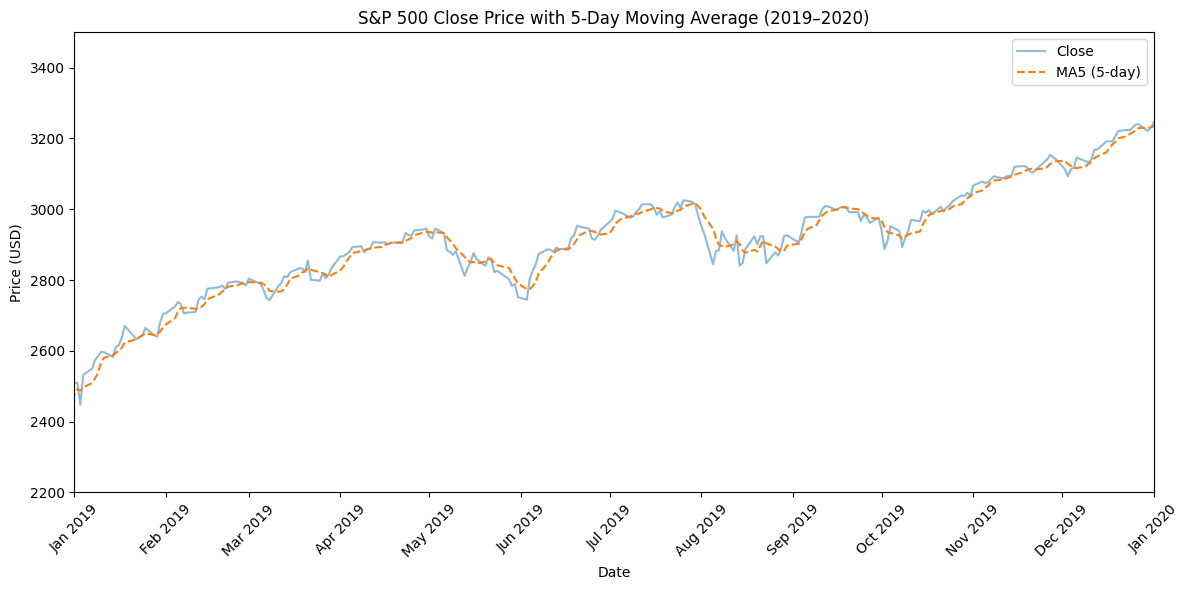

In [15]:
import matplotlib.dates as mdates

# Plot: Close + MA5 with monthly ticks (2019–2020)
fig, ax = plt.subplots(figsize=(12, 6))

# Plot close price and MA5
ax.plot(df['Close'], label='Close', alpha=0.5)
ax.plot(df['MA5'], label='MA5 (5-day)', linestyle='--')

# Set limits
ax.set_xlim(pd.to_datetime(['2019-01-01', '2020-01-01']))
ax.set_ylim(2200, 3500)

# Format x-axis with monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels and title
ax.set_title('S&P 500 Close Price with 5-Day Moving Average (2019–2020)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()

# Final layout adjustments
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


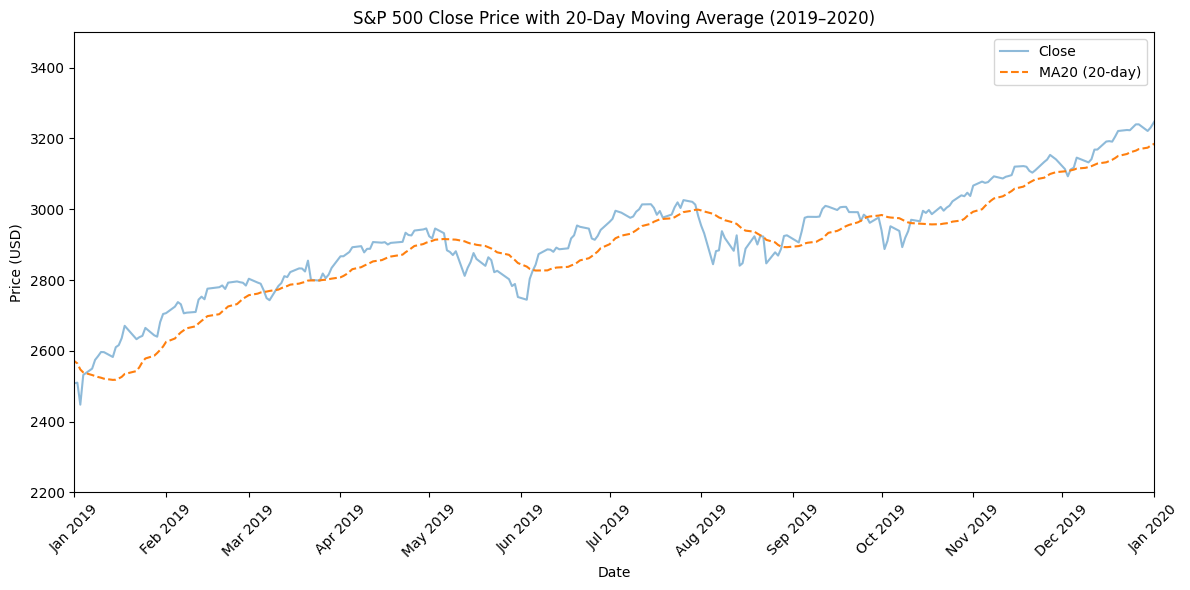

In [16]:
# Plot: Close + MA20 with monthly ticks (2019–2020)
fig, ax = plt.subplots(figsize=(12, 6))

# Plot close price and MA20
ax.plot(df['Close'], label='Close', alpha=0.5)
ax.plot(df['MA20'], label='MA20 (20-day)', linestyle='--')

# Set limits
ax.set_xlim(pd.to_datetime(['2019-01-01', '2020-01-01']))
ax.set_ylim(2200, 3500)

# Format x-axis with monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Labels and title
ax.set_title('S&P 500 Close Price with 20-Day Moving Average (2019–2020)')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()

# Final layout adjustments
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Relative Strength Index (RSI)**

The Relative Strength Index (RSI) is a momentum oscillator  that measures the magnitude of recent price changes to evaluate whether the market is overbought or oversold. It is used to identify potential reversal points or signals indicate trend contiinuation in the same direction.

The RSI ranges from 0-100, with values over 70 being considered overbought and below 30 being considered oversold.

The model can use this feature to account for short-term momentum and can contribute to predicting directional changes in the market.


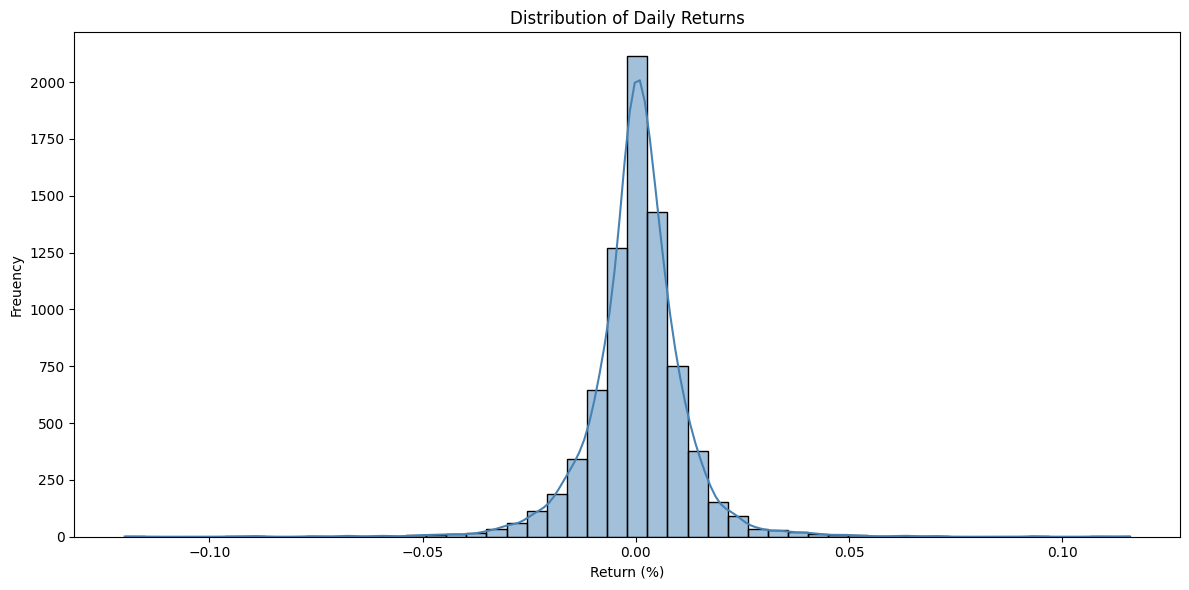

In [17]:
#Plot distribution of daily returns
plt.figure(figsize=(12,6))
sns.histplot(df['Return'], bins = 50, kde = True, color ='steelblue')
plt.title('Distribution of Daily Returns')
plt.xlabel('Return (%)')
plt.ylabel('Freuency')
plt.tight_layout()
plt.show()


In [18]:
#Calculate RSI
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1+rs))

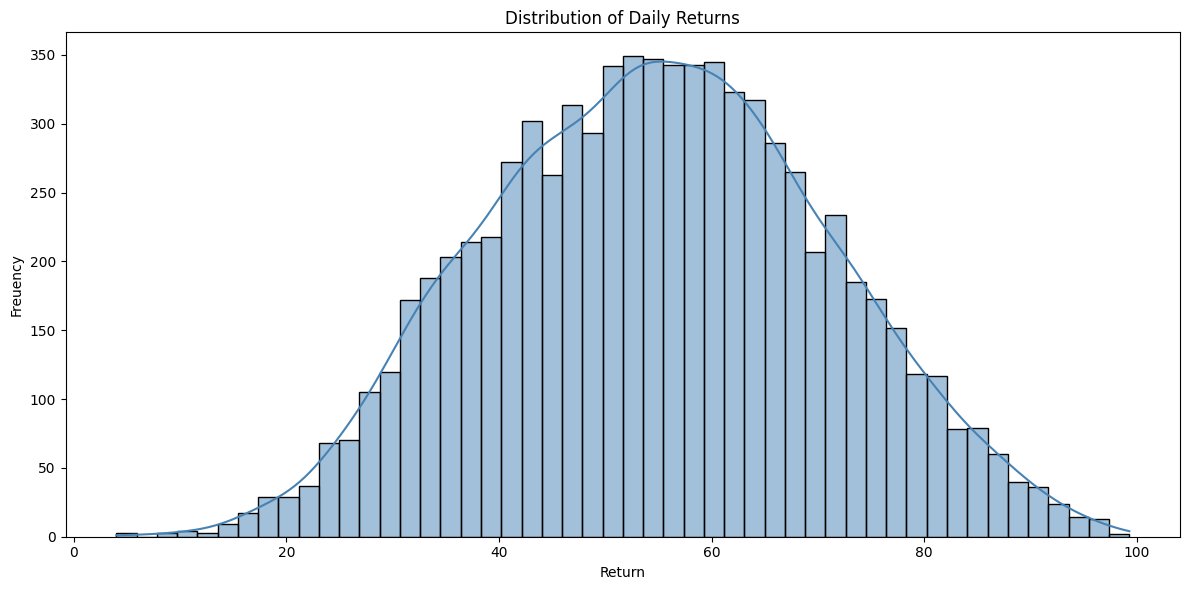

In [19]:
#Plot of RSI distribution
plt.figure(figsize=(12,6))
sns.histplot(df['RSI'], bins = 50, kde = True, color ='steelblue')
plt.title('Distribution of Daily Returns')
plt.xlabel('Return')
plt.ylabel('Freuency')
plt.tight_layout()
plt.show()

**Visualising RSI**

The first plot shows the distribution of day-to-day returns for the S&P 500 index. A sharp peak can be observed, centred at 0, with long tails extending in both directions. This indicates that most daily price changes are very small (close to 0%), but there still remains occasional large positive and negative returns.

The tight and narrow peak represents the noisy nature of the day-to-day returns, where the price changes are often very small and therefore harder to take meaningful trend information from it. This makes it difficult for a model to be able to distinguish actual momentum from random fluctuations when solely using the returns values.

The use of RSI addresses this by aggregating the recent gains and losses into a single value within 0-100. The RSI distribution across the dataset can be seen can be seen in the second plot, having a more even and smooth distribution. RSI also spreads out the heavily concentrated return data and spreads it into a wider, more interpretable scale.

This transformation reduces the effects of short-term volatility and better highlights potential turning points or continuation signals, making is a more informative feature to include in a classification model.




**Rolling Standard Deviation (Volatility)**

Volatility is the statistical measure of the magnitude of price fluctuations over a given time period. It plays a fundamental role in financial markets, as periods of high volatility often correspond to increased fear or uncertainty among market participants, whereas low volatility reflects periods of market stability or indecision. This sentiment is a subsequent consequence of multiple factors, such as economic or geopolitical news.

To quantify this, we calculate the rolling standard deviation of day-to-day returns over a 10 day window, which produces a time-dependent feature that reflects the recent fluctuations in the market, which can be used to assess the current market stability.

The inclusion of volatility allows the model to evaluate the current risk conditions in the market, which can play a major part in influencing the probability of price continuation or price reversal.


In [20]:
#Calculate Rolling std
df['Rolling_STD_10'] = df['Return'].rolling(window=10).std()

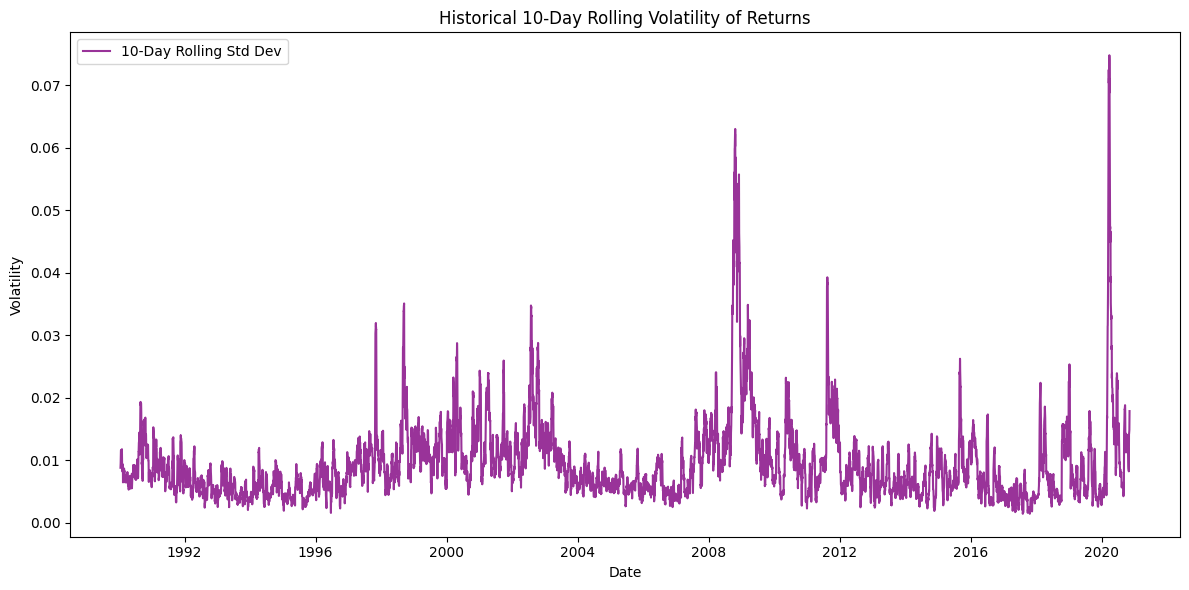

In [21]:
#Plot volatility
plt.figure(figsize=(12, 6))
plt.plot(df['Rolling_STD_10'], label='10-Day Rolling Std Dev', color='purple', alpha=0.8)
plt.title('Historical 10-Day Rolling Volatility of Returns')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.tight_layout()
plt.show()

**Visualising Volatility**

The plot of the 10-day rolling standard deviation of returns across the entire historical range illustrates clear spikes can be seen that represents heightened market volatility, with major spikes aligning with major historical events such as the Black Monday crash in 1987 and the global financial crisis in 2008.This demonstrates the changes in volatility, especially in response to economic uncertainty, which supports its dependence on market conditions and justifies including this feature to capture the recent market risk and its impact on price movement.  

**Lagged Returns**

Financial time series can often show short-term autocorrelation, in which the recent returns may influence the future price movement. This is relevant in this case as  price momentum effects can drive trends for a short period of consecutive days.

The lagged return, which is the return from previous days, has been created as a feature, allowing for identification of recent patterns ans directional trends in price.

1-day,2-day and 3-day lagged returns have been chosen to reflect the short-term autocorrelation and potential price momentum effects.

In [22]:
#Calculate lagged returns
df['Lag1'] = df['Return'].shift(1)
df['Lag2'] = df['Return'].shift(2)
df['Lag3'] = df['Return'].shift(3)

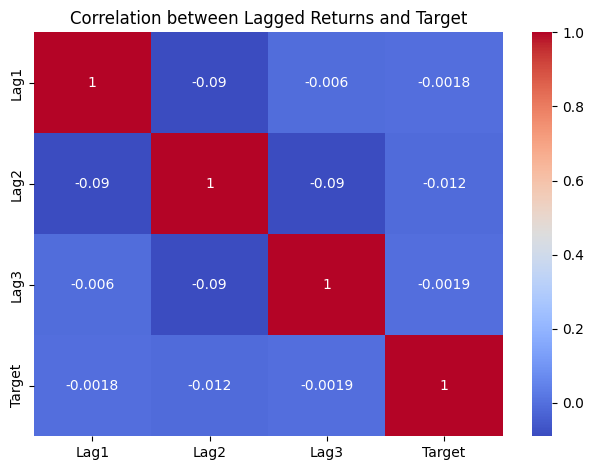

In [23]:
#Plot heatmap of lagged returns
sns.heatmap(df[['Lag1', 'Lag2', 'Lag3', 'Target']].corr(), annot = True, cmap ='coolwarm')
plt.title('Correlation between Lagged Returns and Target')
plt.tight_layout()
plt.show()

**Lagged Return Correlations**

Although the lagged return features do not exhibit a strong linear relationship with the target variable, this is not unexpected due to the data complexity.

The relationship between the lagged return and future price movement is likely to be **non-linear** and is dependent on the market context at the time, so simple correlation metrics can't capture such patterns.

This lack of correlation further highlights the limitations of traditional statistical methods, further justifying the use of machine learning models to identify non-linear relationships within the data.

**Calendar Effect (Day of week and Month)**

Financial markets often display cyclical patterns tied to the calendar. These effects are due to factors such as investor pyschology or timing of economic reports and major events.

Some examples of this are:
-**Day of week**: Markets can behave differently when the market opens for the week on Monday (risk aversion) in comparison to the day the market closes on Friday (profit-taking).
-**Monthly**: Certain months, such as the the beginning of the new year in January,show seasonal trends tied to economic cycles or investment flow.

The dataframe will include two categorical features to represent the month and day of the week for each entry:
- **Day of the week** (0 = Monday, ..., 4 = Friday)
- **Month of the year** (1 = January, ..., 12 = December)

By labelling the data entries in this manner, time-dependent behaviours can be factored into the model.


In [24]:
#Calendar features
df['Dow'] = df.index.dayofweek
df['Month']= df.index.month

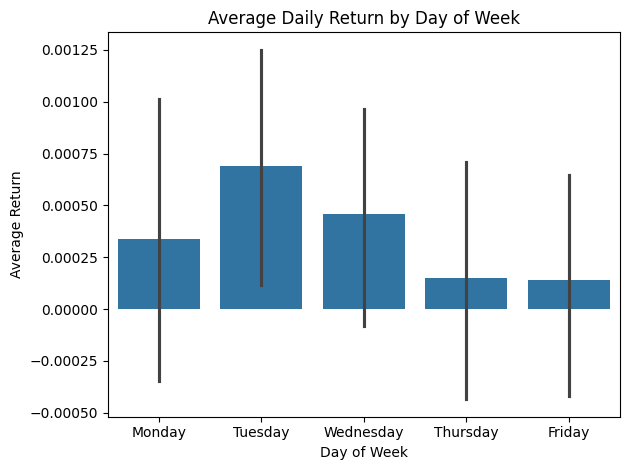

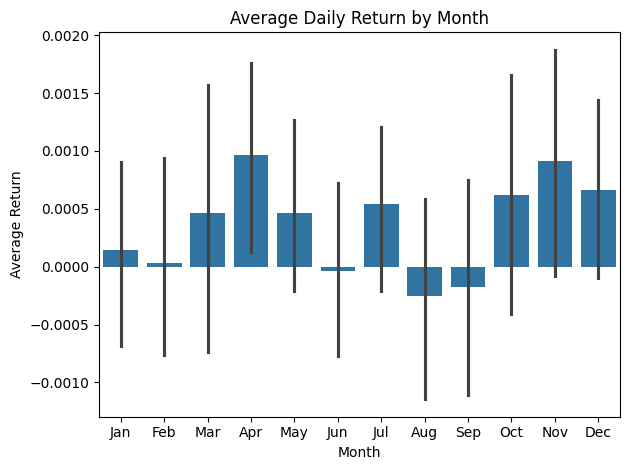

In [25]:
#Average return by day of the week
day_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sns.barplot(x='Dow', y='Return', data=df)
plt.title('Average Daily Return by Day of Week')
plt.xticks(ticks=range(5), labels = day_labels)
plt.xlabel('Day of Week')
plt.ylabel('Average Return')
plt.tight_layout()
plt.show()

#Average return by month
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
sns.barplot(x='Month', y='Return', data=df)
plt.title('Average Daily Return by Month')
plt.xticks(ticks=range(12), labels = month_labels)
plt.xlabel('Month')
plt.ylabel('Average Return')
plt.tight_layout()
plt.show()

**Visualisation of calendar effects**

The first plot shows the average daily return by day of the week. As expected, we can observe that Mondays tend to have negative average returns, which reflects the cautious mark sentiment as the market opens. Wednesdays and Fridays show the highest average returns, reflecting possible mid-week momentum and end-of-week optimism.

The second plot shows the average daily month return by month. The higher returns observed in April, November and December are consistent with known seasonal patterns, with April being the start of a new financial quarter and often coincides with positive earning announcements.


whereas November and December period is commonly known as the  'Santa Claus rally', a period where the strength of the market is attributed to holiday-driven optimism.

These patterns may be able to provide useful seasonal signals in the model.

**Intra-Day Price Range**

The intra-day price range is the difference between the highest and lowest prices on a trading day. This captures the range of price movement during the day.

Large ranges can indicate uncertainty, spikes in volatility, or strong directional movement caused by events. On the other hand, smaller ranges can mean market indecision or consolidation periods where the market is stabilising.

This can be used to identify days with abnormally high or low trading behaviour, adding another way to represent market volatility.

In [26]:
#Create intra-day price range
df['Price_Range'] = df['High'] - df['Low']

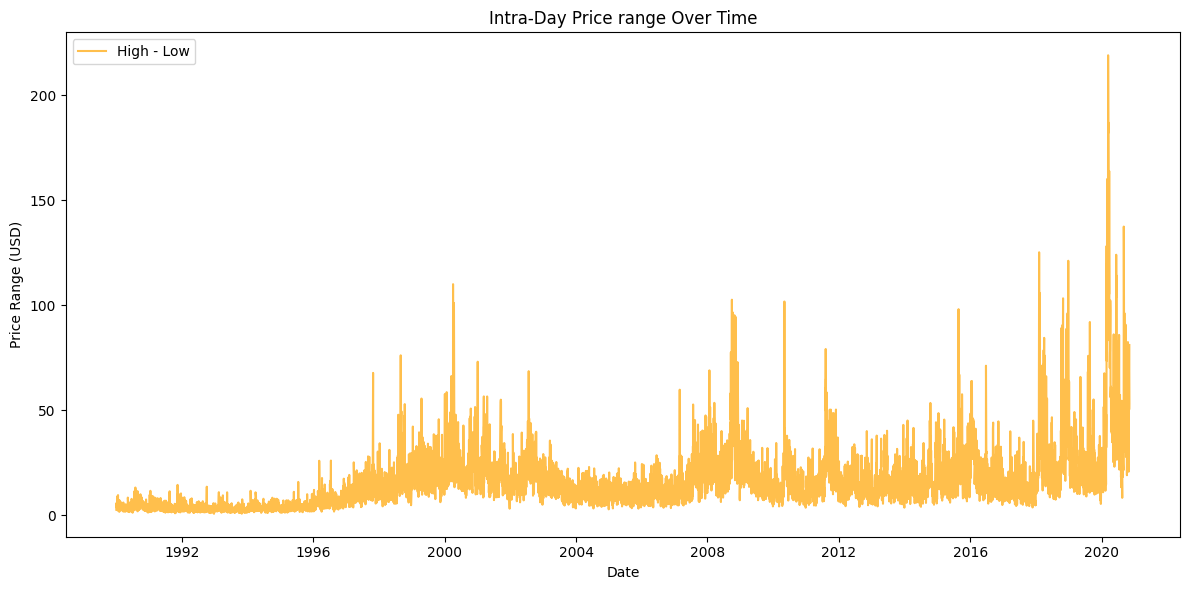

In [27]:
#Plot price range
plt.figure(figsize=(12,6))
plt.plot(df['Price_Range'], label='High - Low', color='orange', alpha=0.7)
plt.title('Intra-Day Price range Over Time')
plt.xlabel('Date')
plt.ylabel('Price Range (USD)')
plt.tight_layout()
plt.legend()
plt.show()

The graph shows that the range before the 1980s is low an stable, but starts to increase in range and fluctuates more significantly after this as trading volume increases and the adoption of algorithmic trading.

Major spikes can be observed during periods of financial stress, such as the 2008 Financial Crisis and the COVID-19 market crash in 2020, successfully capturing short-term uncertainty.

**Standardised Volume (Z-score)**

The z-score quantifies how far a value is from the mean, in terms of how many standard deviations it is away from it. This will be used to measure how unusual the trading volume is on a day, in comparison to the recent average.

A high positive z-score indicates a major increase in trading volume, and a negative scores indicates low trading activity.

This can be used to detect anomalies in trading behaviour that may lead to major price movement.

In [28]:
#Create volume z-score (10 day standardised)
df['Volume_Z'] =(df['Volume'] - df['Volume'].rolling(10).mean()) / df['Volume'].rolling(10).std()

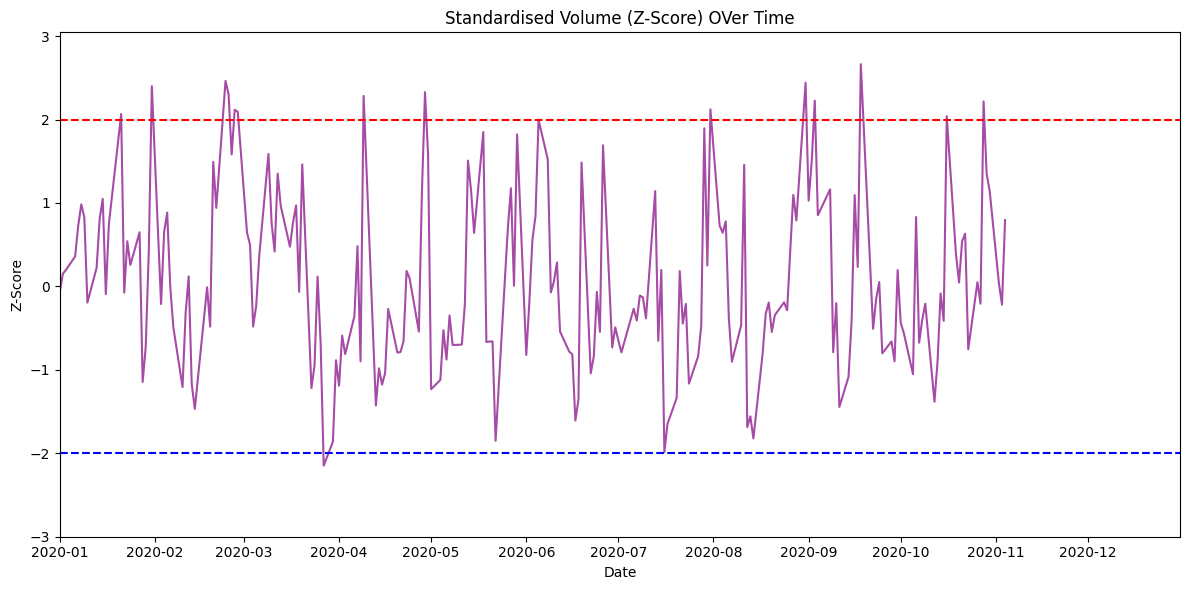

In [29]:
#Plot trading volume
plt.figure(figsize=(12,6))
plt.plot(df['Volume_Z'], label='Volume Z-Score', color='purple', alpha=0.7)
plt.axhline(2, color = 'red', linestyle = '--', label = '+2σ Threshold')
plt.axhline(-2, color = 'blue', linestyle = '--', label = '-2σ Threshold')
plt.title('Standardised Volume (Z-Score) OVer Time')
plt.xlabel('Date')
plt.ylabel('Z-Score')
plt.xlim(pd.to_datetime(['2020-01-01', '2020-12-31']))
plt.tight_layout()
plt.show()

The plot shows the volume z-score plot in 2020. There are peaks and dips seen that represents unusual trading days with either high or low volume. It can be seen that when it reaches +2 or -2 z-score, it usually follows major market movement in the opposite direction.

**Maroeconomic Indicators (Volatility and Interest Rates)**

To improve the predictive power of the model, we have expanded the dataset to include external economic drivers that directly influence the stock movement, rather than using only historical price data.


* VIX (Fear Index): A measurement of market expectation of near-term volatility.
* 10-Year Treasury Yield (Interest Rates): Statistic measure of the risk-free rate of return. We  have calculated the Daily Difference to identify signigicant shifts in the capital cost. A rising rate is often an indication of a declining stock valuation.

We will also lag the values by a day to help the model identify short-term trends and reaction patterns.


In [30]:
#Calculate daily percentage change and 1-day lagged feature for VIX
df['VIX_Change'] = df['VIX'].pct_change()
df['VIX_Lag1'] = df['VIX'].shift(1)

#Calculate daily percentage change and 1-day lagged feature for Interest Rates
df['Interest_Rate_Change'] = df['Interest_Rate'].diff()
df['Interest_Rate_Lag1'] = df['Interest_Rate'].shift(1)

**Feature Consolidation and Dataset Preparations**

**Feature Selection**

Now we have a full set of features that is appropriate for model training, including engineered features that is able to capture useful trends and time-based features. The original dataset variables will be omitted from the dataframe as they are now represented by the engineered features, avoiding redundancy and excess noise.

In [31]:
#List of features that will be used for modelling
features = [
    'Return', 'MA5', 'MA20', 'RSI', 'Rolling_STD_10',
    'Lag1', 'Lag2', 'Lag3', 'Price_Range', 'Volume_Z',
    'DayOfWeek', 'Month',
    'VIX_Change', 'VIX_Lag1',
    'Interest_Rate_Change', 'Interest_Rate_Lag1'
]
#drop NaN values
df.dropna(inplace = True)


The rolling calculations, like the moving averages, will contain NaN values, so these will be removed to avoid errors.

In [32]:
#One-hot encode calendar features
df = pd.get_dummies(df, columns = ['Dow', 'Month'], drop_first=True)

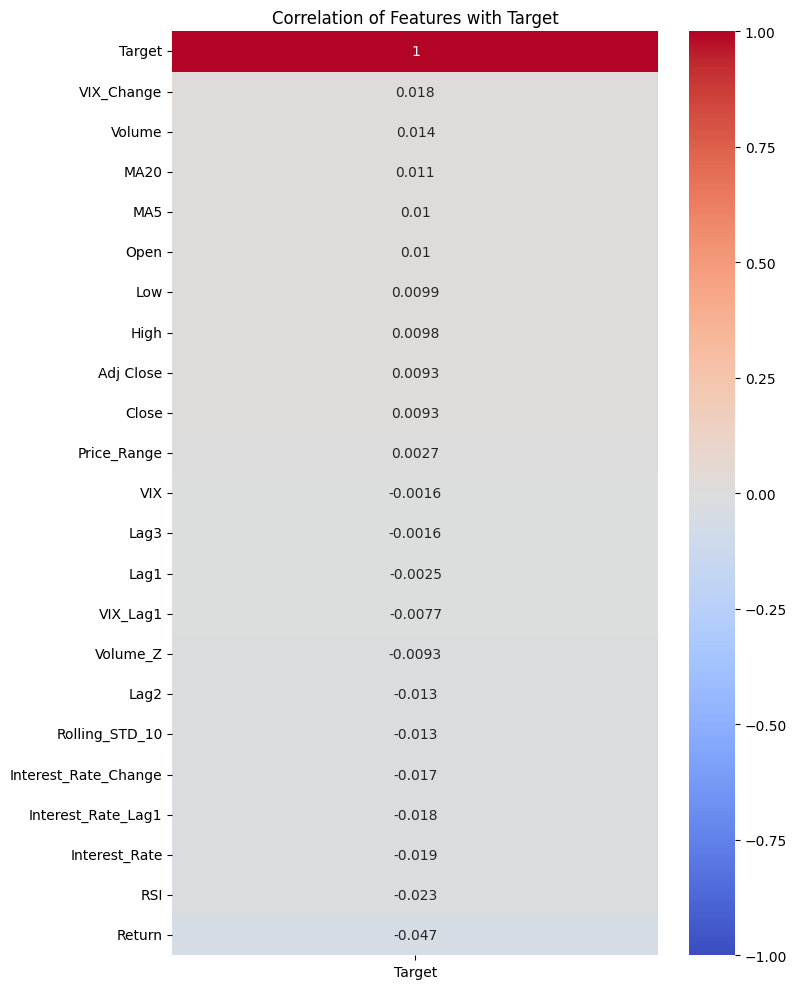

In [33]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation with Target only
correlations = numeric_df.corr()['Target'].sort_values(ascending=False)

# Plot heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(correlations.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Target')
plt.tight_layout()
plt.show()

The correlation heatmap shows low linear correlation with the target variable due to the non-linear and noisy nature of the data, showing the need to capture more complex data relationships with the machine learning model.

Now The features and Target can be set:

In [34]:
X = df.drop(columns=['Target'])
y = df['Target']

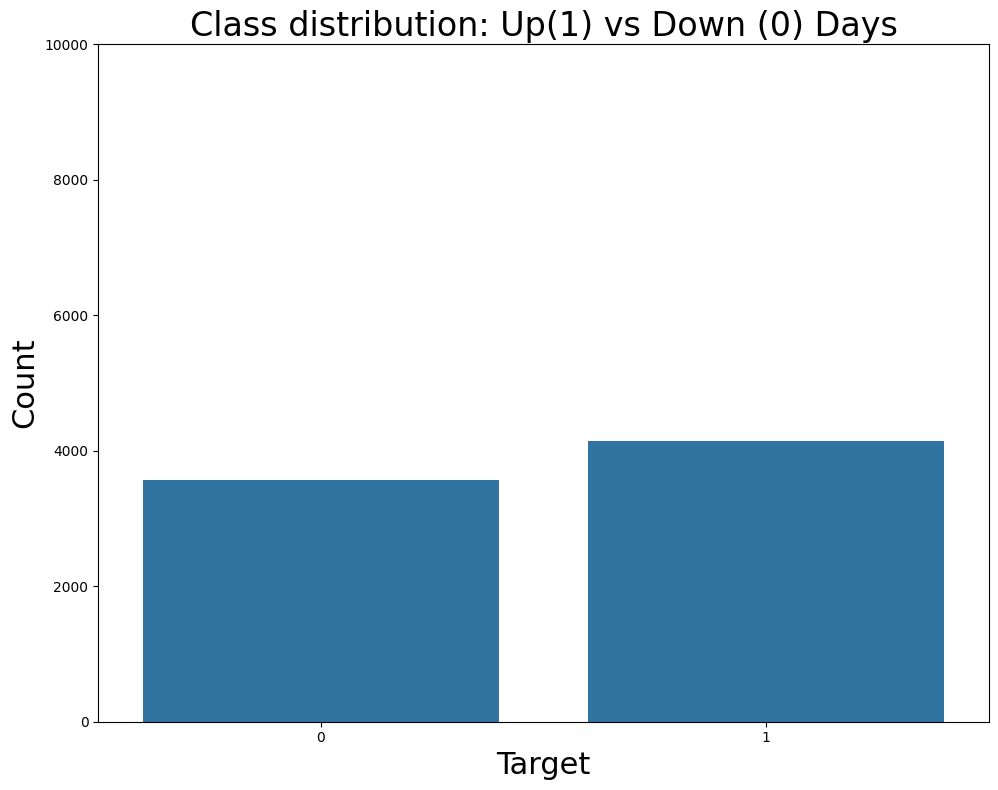

In [35]:
#Visualise class distribution of Target
plt.figure(figsize=(10,8))
sns.countplot(x = 'Target', data = df)
plt.title('Class distribution: Up(1) vs Down (0) Days', fontsize = '24')
plt.xlabel('Target', fontsize =22)
plt.ylabel('Count',  fontsize =22)
plt.tight_layout()
plt.ylim(0,10000)
plt.show()

**Class Balance**

A check has been done on the class balance to ensure there in no major imbalance between the classes. The plot shows an imbalance towards up days, but is expected  as the stock index has a tendency towards long-term growth so there will be more up days. There is no need to rebalance the dataset as doing so would distort the time series structure and would introduce unrealistic patterns. This imbalance implies that a naive model that predicts Up for every day would achieve relatively high accuracy (~54%), so this will be used as the benchmark to evaluate the model performance.


**Train/Test Split**

As this is a time series prediction task, we do not use random_shuffle as the ordering of data is important to maintain. A choronological split is used, taking the first 80% of the data as training data and the final 20% as test data. This should allow the model to attempt to predict future outcomes based on the previous data.

In [36]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_score, accuracy_score, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier


models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=67),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, eval_metric='logloss', random_state=67)
}

tscv = TimeSeriesSplit(n_splits=5)
results = []

for name, model in models.items():
  print(f'Training {name}...')
  fold_precisions = []
  fold_accuracies = []
  fold_recalls = []

  for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    precision = precision_score (y_test, y_pred, zero_division = 0)
    fold_precisions.append(precision)

    accuracy = accuracy_score(y_test, y_pred)
    fold_accuracies.append(accuracy)

    recall = recall_score(y_test, y_pred)
    fold_recalls.append(recall)

  results.append((name, np.mean(fold_precisions), np.mean(fold_accuracies), np.mean(fold_recalls)))


model_test_results_df = pd.DataFrame(results)
model_test_results_df.columns = ['Model', 'Precision', 'Accuracy', 'Recall']
model_test_results_df


Training Random Forest...
Training XGBoost...


,Model,Precision,Accuracy,Recall
0,Random Forest,0.544348,0.503497,0.569952
1,XGBoost,0.548387,0.521523,0.670453


**Model Comparison**

Training and testing the random forest and XGBoost models with default parameters have revealed that XGBoost model is the clear winner when looking at the statistical metrics.


*   Precision and Accuracy: it is marginally better (0.4% and 2.1% respectively)
*   Recall: The most significant difference can be seen in the recall. XGBoost captured the uptrend movements of the stock 67.0% whereas the random forest was able to this at a rate of 57.0%.

This means that the XGBoost model is noticably better at identifying profitable buying opportunities, making it a more profitable and suitable model to tune further.



In [37]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Define hyperparameter Space
param_grid = {
    'n_estimators': [100, 200, 300, 500],      # Number of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],   # How fast the model learns
    'max_depth': [3, 4, 5, 6],                 # How complex each tree is
    'subsample': [0.7, 0.8, 0.9, 1.0],         # Fraction of data to use per tree (prevents overfitting)
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],  # Fraction of features to use per tree
    'gamma': [0, 0.1, 0.2, 0.5]                # Minimum loss reduction to split
}

tscv = TimeSeriesSplit(n_splits=5)

model_to_tune = XGBClassifier(eval_metric='logloss', random_state=67)

print('Tuning XGBoost...')

search = RandomizedSearchCV(
    estimator = model_to_tune,
    param_distributions = param_grid,
    n_iter = 20,
    scoring = 'precision',
    cv = tscv,
    verbose = 1,
    random_state = 67,
    n_jobs = -1
    )

search.fit(X, y)

print('Best Parameters:', search.best_params_)
print('Best Precision:', search.best_score_)

best_model = search.best_estimator_

Tuning XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.7}
Best Precision: 0.5576462184262053



 Final Tuned Model Performance
              precision    recall  f1-score   support

Down Day (0)       0.46      0.09      0.16       706
  Up Day (1)       0.54      0.91      0.68       839

    accuracy                           0.54      1545
   macro avg       0.50      0.50      0.42      1545
weighted avg       0.51      0.54      0.44      1545



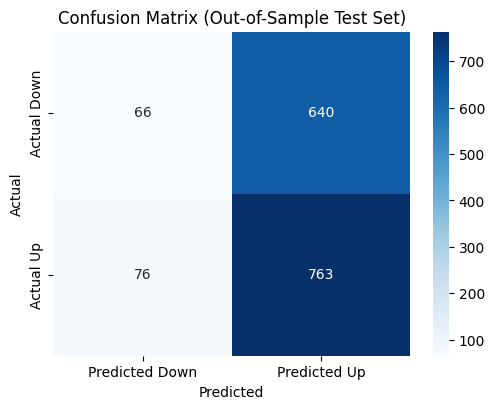

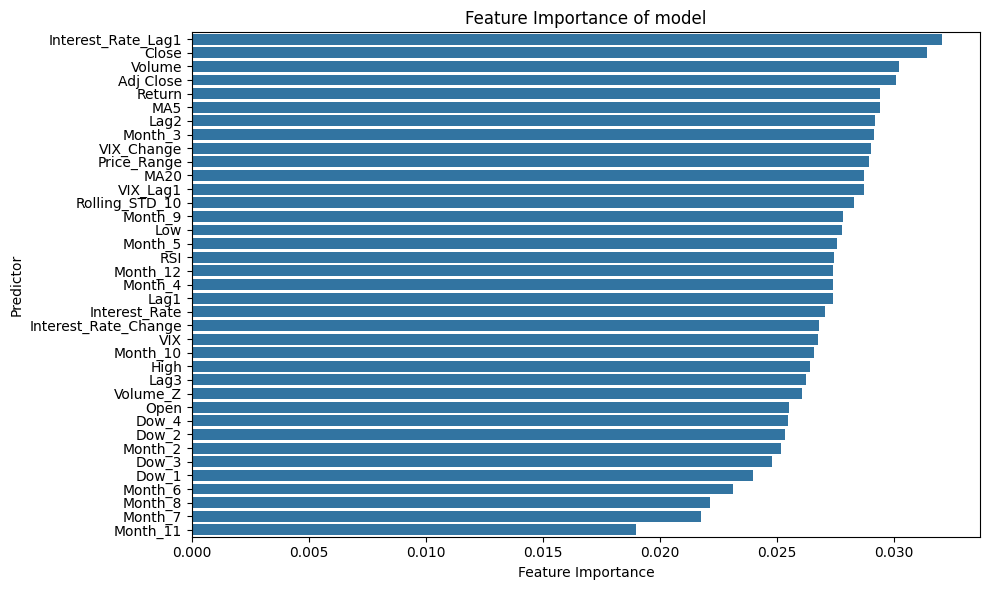

In [38]:
from sklearn.metrics import classification_report, confusion_matrix

train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print('\n Final Tuned Model Performance')
print(classification_report(y_test, y_pred, target_names = ['Down Day (0)', 'Up Day (1)']))

# plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
           xticklabels = ['Predicted Down', 'Predicted Up'],
           yticklabels = ['Actual Down', 'Actual Up']
           )
plt.title('Confusion Matrix (Out-of-Sample Test Set)')
plt.tight_layout()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot feature importance graph
feature_importance = pd.Series(best_model.feature_importances_, index = X_train.columns).sort_values(ascending = False)

plt.figure(figsize = (10,6))
sns.barplot(x = feature_importance, y = feature_importance.index)
plt.title('Feature Importance of model')
plt.xlabel('Feature Importance')
plt.ylabel('Predictor')
plt.tight_layout()
plt.show()


In [39]:
# Baseline: always predict Up (1)
y_pred_baseline = [1] * len(y_test)

from sklearn.metrics import accuracy_score

baseline_acc = accuracy_score(y_test, y_pred_baseline)
model_acc = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_acc)
print("Model Accuracy:", model_acc)

Baseline Accuracy: 0.543042071197411
Model Accuracy: 0.5365695792880258


In [40]:
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Model Accuracy: {model_acc:.3f}")


Baseline Accuracy: 0.543
Model Accuracy: 0.537


In [41]:
export_df = df.iloc[train_size:].copy()

if export_df.index.name == 'Date':
    export_df.reset_index(inplace=True)
else:
    export_df.index.name = 'Date'
    export_df.reset_index(inplace=True)

export_df['Actual_Target'] = y_test
export_df['Model_Prediction'] = y_pred

export_df['Prediction_Correct'] = (export_df['Actual_Target'] == export_df['Model_Prediction']).astype(int)

probs = best_model.predict_proba(X_test)
export_df['Predicted_Up_Probability'] = probs[:, 1]
export_df['Predicted_Down_Probability'] = probs[:, 0]

file_name = 'SP500_Analysis.csv'
export_df.to_csv(file_name, index = False)
print(f'Data exported to {file_name}')

Data exported to SP500_Analysis.csv


..............

In [42]:
print(export_df.head())

        Date         Open         High          Low        Close    Adj Close  \
0 2014-09-17  1999.300049  2010.739990  1993.290039  2001.569946  2001.569946   
1 2014-09-18  2003.069946  2012.339966  2003.069946  2011.359985  2011.359985   
2 2014-09-19  2012.739990  2019.260010  2006.589966  2010.400024  2010.400024   
3 2014-09-22  2009.079956  2009.079956  1991.010010  1994.290039  1994.290039   
4 2014-09-23  1992.780029  1995.410034  1982.770020  1982.770020  1982.770020   

       Volume  Interest_Rate    VIX    Return  ...  Month_8  Month_9  \
0  3209420000          2.600  12.65  0.001296  ...    False     True   
1  3235340000          2.629  12.03  0.004891  ...    False     True   
2  4880220000          2.587  12.11 -0.000477  ...    False     True   
3  3349670000          2.566  13.69 -0.008013  ...    False     True   
4  3279350000          2.535  14.93 -0.005777  ...    False     True   

   Month_10  Month_11  Month_12  Actual_Target  Model_Prediction  \
0     False 

In [43]:
# The .values attribute strips away the index so it fits perfectly
export_df['Actual_Target'] = y_test.values

print(export_df[['Date', 'Actual_Target']].head())
# Check for NaNs in every column
print(export_df.isna().sum())

        Date  Actual_Target
0 2014-09-17              1
1 2014-09-18              0
2 2014-09-19              0
3 2014-09-22              0
4 2014-09-23              1
Date                          0
Open                          0
High                          0
Low                           0
Close                         0
Adj Close                     0
Volume                        0
Interest_Rate                 0
VIX                           0
Return                        0
Target                        0
MA5                           0
MA20                          0
RSI                           0
Rolling_STD_10                0
Lag1                          0
Lag2                          0
Lag3                          0
Price_Range                   0
Volume_Z                      0
VIX_Change                    0
VIX_Lag1                      0
Interest_Rate_Change          0
Interest_Rate_Lag1            0
Dow_1                         0
Dow_2                         0


In [44]:
print(export_df['Prediction_Correct'].value_counts())

Prediction_Correct
0    1545
Name: count, dtype: int64


In [45]:
export_df['Prediction_Correct'] = (export_df['Actual_Target'] == export_df['Model_Prediction']).astype(int)

print("Updated Counts:")
print(export_df['Prediction_Correct'].value_counts())

print(f"\n True Accuracy: {export_df['Prediction_Correct'].mean():.2%}")

Updated Counts:
Prediction_Correct
1    829
0    716
Name: count, dtype: int64

 True Accuracy: 53.66%


In [46]:
file_name = 'SP500_Analysis.csv'
export_df.to_csv(file_name, index = False)
print(f'Data exported to {file_name}')

Data exported to SP500_Analysis.csv


**Key Insights:**

**Model performance and Market Behaviour:**
The model achieves modest predictive performance (~54% accuracy), around the same value of the naive majority-class baseline, reflecting the inherent difficulty of forecasting short-term market movements. 
Performance is asymmetric, with strong recall for upward movements (~91%) but poor detection of downward movements (~9%).

**Upward Bias and Class Imbalance:**
The model indicates a clear bias towards Up days, which is a result of the overall upward trend of the index. This indicates that the model is partially exploiting the class imbalance rather than learning any meaningful predictive signals. 

**Regime Dependence:**
The rolling accuracy shows that the model performance is regime-dependent, showing improvement in performance during stable periods and deteriorates below the baseline during structural breaks (e.g Brexit, COVID-19).
This highlights the non-stationary nature of financial time series, where the relationships between features and returns are not set variables; rather they change over time with different market conditions.

**Limitations in Risk Detection:**
The model performs poorly in identifying downwards movement, which are less frequent but just as, if not more impactful than its counterpart. This means that there is limited practical use in risk-sensitive or trading applications.

**Key Takeaway:**
Overall, the results have illustrated that while machine learning can capture weak signals in the financial data, the predictive power is neither stable nor significant for practical use, particularly across different market regimes. 

**Limitations And Future Work:**

The model does not outperform the naive majority-class baseline, suggesting that the predictive signal in the chosen features is weak. 
Financial markets are inherently noisy and constantly changing, so the relationships between the variables can change over time, causing changes in model performance.
THe model primarily captures the market drift rather than any meaningful relationships.

**Data Limitations:**
The features used are largely derived from price and available to the public, so is likely the reason why no strong predictive edges could be found.
More informative signals may require:
higher frequency of data
Order book dynamics
alternative data sources (market sentiment, macro expectations etc.)

**Model Considerations:**
Increasing model complexity, such as the use of neural networks, may not necessarily improve performance without stronger underlying data used to train and test with, and may increase the chances of overfitting.
Further work should initially focus on feature quality and data enrichment over model complexity.